# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nayla Poetri Kurnia
- **Email:** cdcc200d6x2356@student.devacademy.id
- **ID Dicoding:** nayla_poetri

## Pertanyaan Bisnis

Analisis ini difokuskan pada periode tahun 2011–2012 sesuai dengan cakupan dataset, dengan tujuan untuk memahami pola dan faktor yang memengaruhi jumlah penyewaan sepeda.

1. Bagaimana pengaruh kondisi cuaca (temperatur, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda pada periode 2011–2012?

2. Pada musim apa jumlah penyewaan sepeda paling tinggi dan paling rendah selama periode 2011–2012?

3. Bagaimana tren perubahan jumlah penyewaan sepeda dari waktu ke waktu dari Januari 2011 hingga Desember 2012?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [3]:
# Load dataset
bike_sharing_df = pd.read_csv("data/day.csv")

bike_sharing_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,kategori_sewa,temp_group
0,1,2011-01-01,Spring,0,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985,Low,Medium Temp
1,2,2011-01-02,Spring,0,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801,Low,Medium Temp
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Low,Low Temp
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Low,Low Temp
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Low,Low Temp


**Insight** Dataset berhasil dimuat dan berisi informasi penyewaan sepeda harian, termasuk variabel cuaca, waktu, dan jumlah penyewaan. Struktur data sudah sesuai dan siap untuk proses analisis lebih lanjut.

### Assessing Data

In [4]:
# Menampilkan informasi dataset
bike_sharing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   instant        731 non-null    int64  
 1   dteday         731 non-null    object 
 2   season         731 non-null    object 
 3   yr             731 non-null    int64  
 4   mnth           731 non-null    int64  
 5   holiday        731 non-null    int64  
 6   weekday        731 non-null    int64  
 7   workingday     731 non-null    int64  
 8   weathersit     731 non-null    object 
 9   temp           731 non-null    float64
 10  atemp          731 non-null    float64
 11  hum            731 non-null    float64
 12  windspeed      731 non-null    float64
 13  casual         731 non-null    int64  
 14  registered     731 non-null    int64  
 15  cnt            731 non-null    int64  
 16  kategori_sewa  731 non-null    object 
 17  temp_group     731 non-null    object 
dtypes: float64

In [5]:
# Statistik deskriptif
bike_sharing_df.describe()

,instant,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
# Mengecek missing values
bike_sharing_df.isnull().sum()  

instant          0
dteday           0
season           0
yr               0
mnth             0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
atemp            0
hum              0
windspeed        0
casual           0
registered       0
cnt              0
kategori_sewa    0
temp_group       0
dtype: int64

In [7]:
# Mengecek duplikasi
bike_sharing_df.duplicated().sum()

np.int64(0)

**Insight** Dataset memiliki 731 baris dan 18 kolom dengan tipe data yang sesuai. Tidak ditemukan missing values maupun data duplikat. Variabel kategori seperti season dan weathersit juga memiliki nilai yang konsisten. Secara keseluruhan, kualitas data sudah baik dan siap untuk tahap cleaning dan analisis lebih lanjut.

### Data Cleaning

Pada tahap ini dilakukan transformasi data untuk meningkatkan keterbacaan dan kemudahan analisis.

In [8]:
# Mengubah tipe data kolom tanggal menjadi datetime
bike_sharing_df["dteday"] = pd.to_datetime(bike_sharing_df["dteday"])

bike_sharing_df.dtypes

instant                   int64
dteday           datetime64[ns]
season                   object
yr                        int64
mnth                      int64
holiday                   int64
weekday                   int64
workingday                int64
weathersit               object
temp                    float64
atemp                   float64
hum                     float64
windspeed               float64
casual                    int64
registered                int64
cnt                       int64
kategori_sewa            object
temp_group               object
dtype: object

In [9]:
# Cek missing value setelah cleaning
bike_sharing_df.isnull().sum()

instant          0
dteday           0
season           0
yr               0
mnth             0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
atemp            0
hum              0
windspeed        0
casual           0
registered       0
cnt              0
kategori_sewa    0
temp_group       0
dtype: int64

In [11]:
print("Jumlah duplikasi",  bike_sharing_df.duplicated().sum())

Jumlah duplikasi 0


In [10]:
# Statistik akhir
bike_sharing_df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [12]:
# Menyimpan dataset setelah cleaning
bike_sharing_df.to_csv("dashboard/main_data.csv", index=False)

**Insight** Dataset tidak memiliki missing values maupun duplikasi, dan tipe data sudah sesuai (termasuk konversi `dteday` ke datetime). Data siap digunakan untuk analisis lanjutan.

## Exploratory Data Analysis (EDA)

In [13]:
bike_sharing_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,kategori_sewa,temp_group
212,213,2011-08-01,Fall,0,8,0,1,1,Clear,0.771667,0.703292,0.550833,0.156717,729,3537,4266,Medium,High Temp
334,335,2011-12-01,Winter,0,12,0,4,1,Clear,0.312500,0.305554,0.524583,0.220158,182,3545,3727,Medium,Low Temp
573,574,2012-07-27,Fall,1,7,0,5,1,Clear,0.781667,0.734217,0.594583,0.152992,1259,5645,6904,High,High Temp
469,470,2012-04-14,Summer,1,4,0,6,0,Clear,0.495000,0.487996,0.502917,0.190917,2795,4665,7460,High,Medium Temp
584,585,2012-08-07,Fall,1,8,0,2,1,Mist,0.735833,0.697621,0.703750,0.116908,1278,5995,7273,High,High Temp


In [14]:
bike_sharing_df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (temperatur, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda pada periode 2011–2012?

Temp vs Cnt


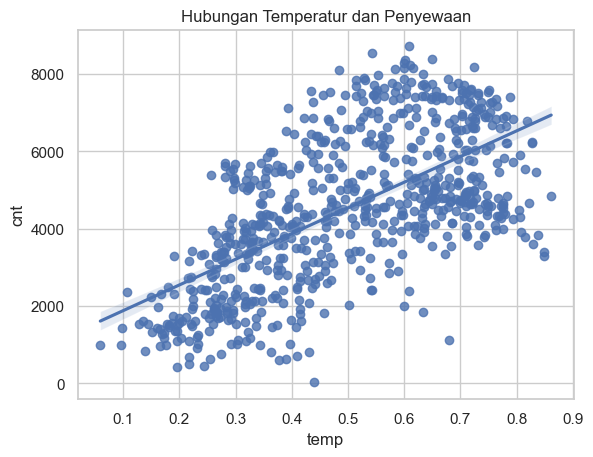

In [15]:
# Hubungan temperatur dengan penyewaan
print("Temp vs Cnt")
sns.regplot(x="temp", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Temperatur dan Penyewaan")
plt.show()

Hum vs Cnt


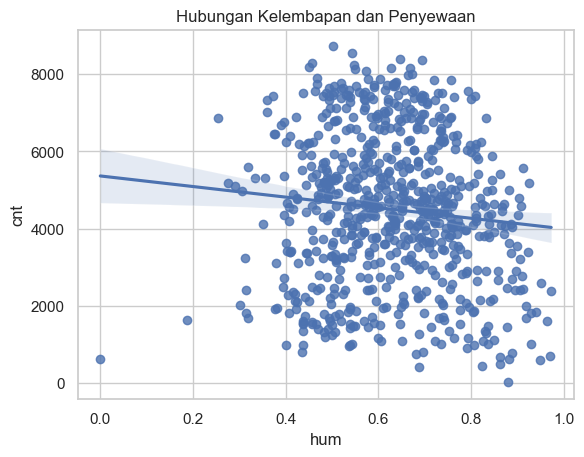

In [16]:
# Hubungan kelembapan dengan penyewaan
print("Hum vs Cnt")
sns.regplot(x="hum", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Kelembapan dan Penyewaan")
plt.show()

Windspeed vs Cnt


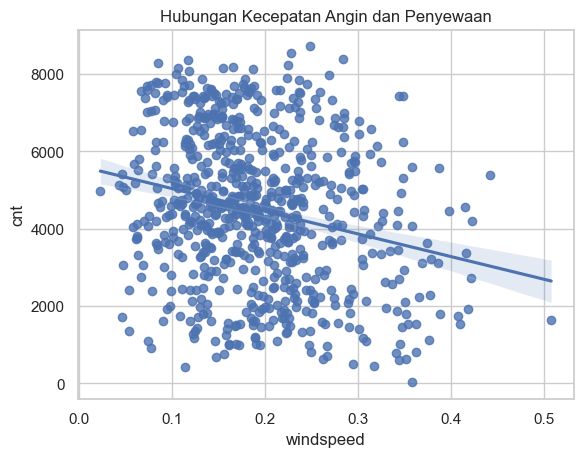

In [17]:
# Hubungan kecepatan angin dengan penyewaan
print("Windspeed vs Cnt")
sns.regplot(x="windspeed", y="cnt", data=bike_sharing_df)
plt.title("Hubungan Kecepatan Angin dan Penyewaan")
plt.show()

Berdasarkan visualisasi hubungan antara variabel cuaca dan jumlah penyewaan sepeda pada periode **2011–2012**, terlihat bahwa **temperatur (temp)** memiliki hubungan **positif yang cukup kuat** terhadap jumlah penyewaan sepeda (**cnt**), yang ditunjukkan oleh pola titik yang cenderung meningkat serta garis regresi yang menanjak. Sebaliknya, **kelembapan (hum)** dan **kecepatan angin (windspeed)** menunjukkan hubungan **negatif yang relatif lemah**, terlihat dari garis tren yang menurun dengan sebaran data yang cukup luas dan cenderung acak, sehingga pengaruhnya tidak dominan. Secara keseluruhan, dapat disimpulkan bahwa **temperatur merupakan faktor yang paling berpengaruh** terhadap jumlah penyewaan sepeda, sedangkan **kelembapan dan kecepatan angin hanya memberikan pengaruh tambahan yang relatif kecil**.

### Pertanyaan 2: Pada musim apa jumlah penyewaan sepeda paling tinggi dan paling rendah selama periode 2011–2012?

,season,total_rentals
0,Spring,471348
1,Summer,918589
2,Fall,1061129
3,Winter,841613


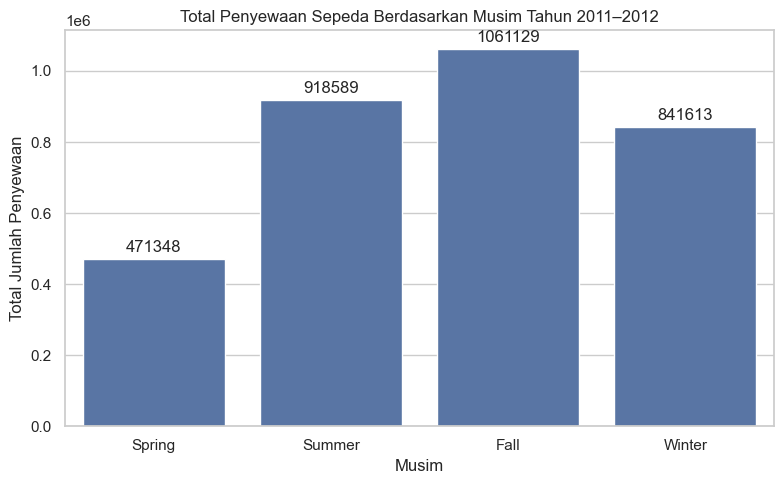

Jumlah penyewaan tertinggi terjadi pada musim Fall dengan total 1,061,129 penyewaan.
Jumlah penyewaan terendah terjadi pada musim Spring dengan total 471,348 penyewaan.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

urutan_musim = ["Spring", "Summer", "Fall", "Winter"]

# Menghitung total penyewaan sepeda pada setiap musim
season_total = (
    bike_sharing_df.groupby("season", observed=False)["cnt"]
    .sum()
    .reindex(urutan_musim)
    .reset_index()
)

season_total.columns = ["season", "total_rentals"]

# Menampilkan tabel hasil
display(season_total)

# Membuat grafik
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=season_total,
    x="season",
    y="total_rentals",
    order=urutan_musim,
    errorbar=None
)

# Menampilkan nilai pada setiap batang
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Total Penyewaan Sepeda Berdasarkan Musim Tahun 2011–2012")
plt.xlabel("Musim")
plt.ylabel("Total Jumlah Penyewaan")
plt.tight_layout()
plt.show()

# Menentukan musim tertinggi dan terendah
musim_tertinggi = season_total.loc[
    season_total["total_rentals"].idxmax()
]

musim_terendah = season_total.loc[
    season_total["total_rentals"].idxmin()
]

print(
    f"Jumlah penyewaan tertinggi terjadi pada musim "
    f"{musim_tertinggi['season']} dengan total "
    f"{musim_tertinggi['total_rentals']:,.0f} penyewaan."
)

print(
    f"Jumlah penyewaan terendah terjadi pada musim "
    f"{musim_terendah['season']} dengan total "
    f"{musim_terendah['total_rentals']:,.0f} penyewaan."
)

Berdasarkan visualisasi rata-rata jumlah penyewaan sepeda berdasarkan musim pada periode **2011–2012**, terlihat bahwa jumlah penyewaan tertinggi terjadi pada **musim gugur (fall)**, diikuti oleh **musim panas (summer)** dan **musim dingin (winter)**, sedangkan **musim semi (spring)** memiliki jumlah penyewaan terendah. Pola ini menunjukkan bahwa kondisi musim memiliki pengaruh terhadap tingkat penyewaan sepeda, di mana cuaca yang lebih nyaman cenderung meningkatkan aktivitas penyewaan. Secara keseluruhan, dapat disimpulkan bahwa **musim merupakan faktor yang memengaruhi variasi jumlah penyewaan sepeda**, dengan puncak aktivitas terjadi pada periode dengan kondisi lingkungan yang lebih mendukung.

### Pertanyaan 3: Bagaimana tren perubahan jumlah penyewaan sepeda dari waktu ke waktu dari Januari 2011 hingga Desember 2012?

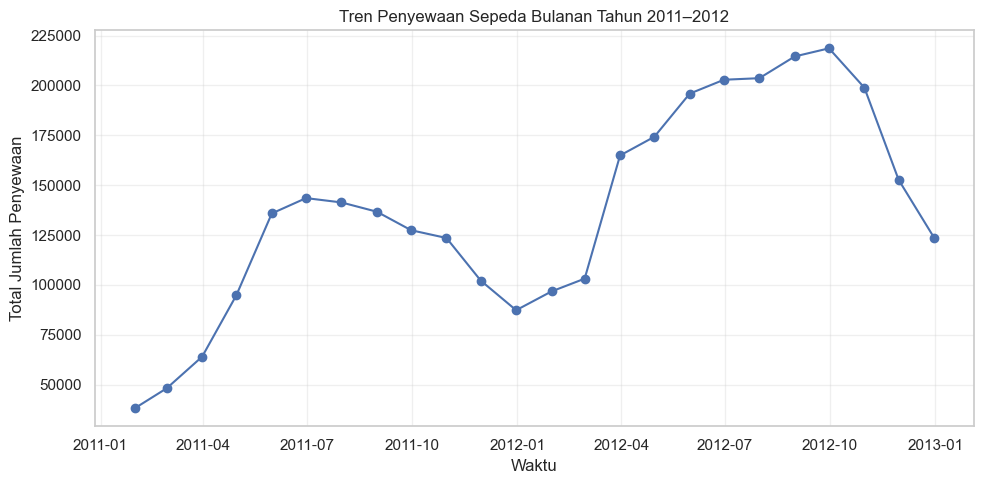

In [21]:
# Membuat salinan data agar data asli tidak berubah
monthly_df = bike_sharing_df.copy()

# Mengubah kolom dteday menjadi tipe datetime
monthly_df["dteday"] = pd.to_datetime(monthly_df["dteday"])

# Menghitung total penyewaan setiap bulan
monthly = (
    monthly_df
    .set_index("dteday")
    .resample("ME")["cnt"]
    .sum()
)

# Membuat visualisasi tren bulanan
plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker="o")

plt.title("Tren Penyewaan Sepeda Bulanan Tahun 2011–2012")
plt.xlabel("Waktu")
plt.ylabel("Total Jumlah Penyewaan")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan analisis tren bulanan pada periode **Januari 2011 hingga Desember 2012**, terlihat bahwa jumlah penyewaan sepeda menunjukkan pola **fluktuatif dengan kecenderungan meningkat** dari waktu ke waktu. Pada kedua tahun, jumlah penyewaan cenderung meningkat dari awal tahun dan mencapai puncak pada **pertengahan hingga akhir tahun**, kemudian menurun kembali menjelang akhir periode. Selain itu, terlihat bahwa tingkat penyewaan pada **tahun 2012 secara umum lebih tinggi dibandingkan tahun 2011**, yang mengindikasikan adanya peningkatan permintaan secara keseluruhan. Pola ini juga menunjukkan adanya **pengaruh musiman**, di mana periode dengan kondisi cuaca yang lebih mendukung cenderung memiliki jumlah penyewaan yang lebih tinggi.

## Conclusion & Recommendation

## Conclusion

- **Conclusion pertanyaan 1:** Temperatur (temp) memiliki hubungan positif yang paling kuat terhadap jumlah penyewaan sepeda (cnt), di mana peningkatan temperatur diikuti oleh peningkatan jumlah penyewaan. Sebaliknya, kelembapan (hum) dan kecepatan angin (windspeed) memiliki hubungan negatif yang relatif lemah, sehingga bukan faktor utama dalam menentukan permintaan.

- **Conclusion pertanyaan 2:** Pola penyewaan sepeda menunjukkan adanya seasonality, di mana jumlah penyewaan tertinggi terjadi pada musim Fall, diikuti oleh Summer dan Winter, sedangkan Spring memiliki jumlah penyewaan terendah. Hal ini menunjukkan bahwa kondisi musim berpengaruh terhadap aktivitas penyewaan sepeda.

- **Conclusion pertanyaan 3:** Tren penyewaan sepeda dari Januari 2011 hingga Desember 2012 menunjukkan pola fluktuatif dengan kecenderungan meningkat. Puncak penyewaan terjadi pada pertengahan hingga akhir tahun, dan secara umum tingkat penyewaan pada tahun 2012 lebih tinggi dibandingkan tahun 2011.

## Rekomendasi

- Optimalisasi ketersediaan sepeda pada periode high demand (Summer–Fall) dengan meningkatkan jumlah unit dan kesiapan operasional  
- Menggunakan temperatur sebagai indikator utama dalam memprediksi permintaan penyewaan  
- Menerapkan strategi promosi pada periode permintaan rendah, seperti Spring atau saat kondisi cuaca kurang mendukung  
- Memanfaatkan tren historis untuk perencanaan distribusi sepeda dan pengelolaan kapasitas secara lebih efisien  